In [17]:
#importing depedencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [18]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
#importing yfinance
import yfinance as yf
nifty=yf.download("EURUSD=X",start="2010-01-01", interval="1d")  #National stock exchange of India
print(nifty.tail())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2026-03-03  1.169727  1.170713  1.153203  1.169454        0
2026-03-04  1.161224  1.165488  1.157675  1.161090        0
2026-03-05  1.163562  1.164687  1.156190  1.163521        0
2026-03-06  1.160807  1.162250  1.154761  1.160712        0
2026-03-09  1.158346  1.161980  1.151145  1.161845        0


In [20]:
nifty.describe()

Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
count,4212.000000,4212.000000,4212.000000,4212.000000,4212.0
mean,1.186340,1.190375,1.182140,1.186361,0.0
std,0.111471,0.112056,0.111049,0.111527,0.0
min,0.959619,0.967006,0.760572,0.959619,0.0
25%,1.098298,1.101928,1.094337,1.098225,0.0
50%,1.158031,1.161206,1.154374,1.158091,0.0
75%,1.282080,1.287529,1.276691,1.282545,0.0
max,1.484406,1.493808,1.480494,1.484296,0.0


In [21]:
nifty.tail(10)

Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2026-02-24,1.179384,1.179663,1.176734,1.179315,0
2026-02-25,1.177523,1.180791,1.177135,1.177551,0
2026-02-26,1.181516,1.183012,1.178245,1.181544,0
2026-02-27,1.180303,1.182396,1.179051,1.180345,0
2026-03-02,1.175945,1.179579,1.167283,1.176014,0
2026-03-03,1.169727,1.170713,1.153203,1.169454,0
2026-03-04,1.161224,1.165488,1.157675,1.161090,0
2026-03-05,1.163562,1.164687,1.156190,1.163521,0


In [22]:
print(nifty.columns)

MultiIndex([( 'Close', 'EURUSD=X'),
            (  'High', 'EURUSD=X'),
            (   'Low', 'EURUSD=X'),
            (  'Open', 'EURUSD=X'),
            ('Volume', 'EURUSD=X')],
           names=['Price', 'Ticker'])


In [23]:
nifty.columns = nifty.columns.get_level_values(0)

In [24]:
import yfinance as yf

nifty = yf.download("EURUSD=X", start="2010-01-01")

# flatten columns
nifty.columns = nifty.columns.get_level_values(0)

# create target
nifty['Tomorrow'] = nifty['Close'].shift(-1)

nifty['Target'] = (nifty['Tomorrow'] > nifty['Close']).astype(int)

nifty = nifty.dropna()

[*********************100%***********************]  1 of 1 completed


In [25]:
import yfinance as yf

# Define the ticker symbol
ticker_symbol = "TSLA"

# Create a Ticker object
ticker = yf.Ticker(ticker_symbol)

# Fetch historical market data
historical_data = ticker.history(period="2y")  # data for the last year
print("Historical Data:")
print(historical_data)

# Fetch basic financials
financials = ticker.financials
print("\nFinancials:")
print(financials)

# Fetch stock actions like dividends and splits
actions = ticker.actions
print("\nStock Actions:")
print(actions)



Historical Data:
                                 Open        High         Low       Close  \
Date                                                                        
2024-03-11 00:00:00-04:00  175.449997  182.869995  174.800003  177.770004   
2024-03-12 00:00:00-04:00  177.770004  179.429993  172.410004  177.539993   
2024-03-13 00:00:00-04:00  173.050003  176.050003  169.149994  169.479996   
2024-03-14 00:00:00-04:00  167.770004  171.169998  160.509995  162.500000   
2024-03-15 00:00:00-04:00  163.160004  165.179993  160.759995  163.570007   
...                               ...         ...         ...         ...   
2026-03-03 00:00:00-05:00  395.089996  396.339996  385.390015  392.429993   
2026-03-04 00:00:00-05:00  397.850006  408.329987  394.579987  405.940002   
2026-03-05 00:00:00-05:00  401.570007  408.619995  399.420013  405.549988   
2026-03-06 00:00:00-05:00  398.089996  402.350006  394.209991  396.730011   
2026-03-09 00:00:00-04:00  390.049988  392.989990  381.3999

In [ ]:
# momentum trading strategies-if last 3 days returns are positive → price likely to continue upward

In [26]:
# Price return (daily percentage change)
nifty['Return'] = nifty['Close'].pct_change()
# return = close(t)-close(t-1)/close(t-1) This calculates the percentage change between today's closing price and yesterday's closing price
# Moving averages
# return = close(t)-close(t-1)-close(t-2).....close(t-5)/5   This calculates the average closing price of the last 5 days.
nifty['MA5'] = nifty['Close'].rolling(5).mean() 
nifty['MA20'] = nifty['Close'].rolling(20).mean()

# Volatility   Volatility=Std(Returnt​,Returnt−1​,Returnt−2​,...) This calculates the standard deviation of returns over the last 5 days.
#Low SD-values are close together
#high SD- Values fluctuate
nifty['Volatility'] = nifty['Return'].rolling(5).std()

# Price momentum
nifty['Momentum'] = nifty['Close'] - nifty['Close'].shift(5)

In [15]:
print(nifty['Return'])

Date
2010-01-01         NaN
2010-01-04    0.002366
2010-01-05   -0.004022
2010-01-06    0.002650
2010-01-07   -0.005971
                ...   
2026-03-02   -0.003692
2026-03-03   -0.005287
2026-03-04   -0.007269
2026-03-05    0.002013
2026-03-06   -0.002368
Name: Return, Length: 4211, dtype: float64


In [16]:
print(nifty['MA5'])
print(nifty['MA20'])

Date
2010-01-01         NaN
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07    1.438039
                ...   
2026-03-02    1.178934
2026-03-03    1.177003
2026-03-04    1.173743
2026-03-05    1.170152
2026-03-06    1.166253
Name: MA5, Length: 4211, dtype: float64
Date
2010-01-01         NaN
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
                ...   
2026-03-02    1.182335
2026-03-03    1.181828
2026-03-04    1.180808
2026-03-05    1.179978
2026-03-06    1.179129
Name: MA20, Length: 4211, dtype: float64


In [ ]:
features = ['Return','MA5','MA20','Volatility','Momentum']
# setting X and y features

X = nifty[features]
y = nifty['Target']

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,shuffle=False)


In [35]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.4/101.7 MB 19.1 MB/s eta 0:00:06
   - -------------------------------------- 4.5/101.7 MB 12.2 MB/s eta 0:00:08
   -- ------------------------------------- 5.8/101.7 MB 9.4 MB/s eta 0:00:11
   -- ------------------------------------- 6.8/101.7 MB 8.4 MB/s eta 0:00:12
   -- ------------------------------------- 7.3/101.7 MB 7.3 MB/s eta 0:00:13
   -- ------------------------------------- 7.6/101.7 MB 6.3 MB/s eta 0:00:15
   --- ------------------------------------ 8.1/101.7 MB 5.6 MB/s eta 0:00:17
   --- ------------------------------------ 9.2/101.7 MB 5.4 MB/s eta 0:00:18
   ---- ----------------------------------- 10.5/101.7 MB 5.5 MB/s eta 0:00:17
   ---- ----------------------------------- 12.3/101.7 MB 5.8 MB/s eta 0:00:16
   ----- ---------------------------------- 13.1/101.7 MB 5.7 MB/s eta 0:00:16
   ----- ---------------------------------- 14.2/101.7 MB 5.6 MB/s


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# XGboost model
# 1st I used regresssor but while checking the accuracy it showed the error becasue one variable is classification, but the other is regression output.
# thats why i used XGBRegressor predicts because it used continuous values.
from xgboost import XGBClassifier

In [42]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
features = [
    "MA_20",
    "RSI",
    "MACD",
    "Bollinger_Upper",
    "Bollinger_Lower",
    "Volume"
]

In [43]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
predictions = model.predict(X_test)

print(predictions)

[1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 1 1
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 0 1
 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 0 1 1
 1 0 1 0 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 0 0
 0 0 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 0 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0 0 0 1 1 1 0 1 0 0 1 0 0 0 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 0 1 0 0 0
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0
 0 1 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 0 0 1 

In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5088967971530249


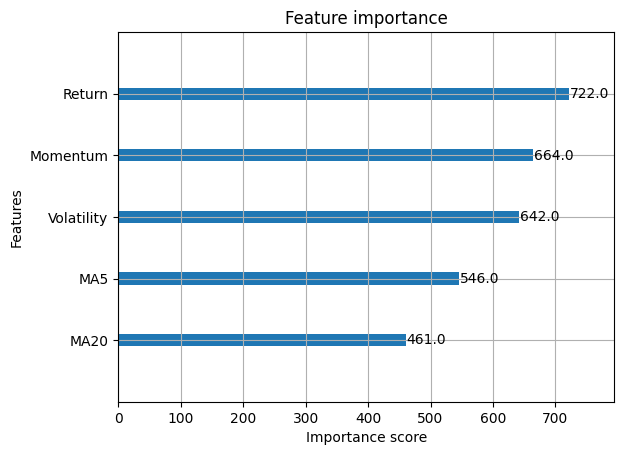

In [46]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()